In [ ]:
import logging

logging.basicConfig(
    filename="day1.log",
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s",
)
logger = logging.getLogger("internship_day1")
print("Logging configured -> day1.log")

# Log your entries below, e.g.:
# logger.info("Set up local Postgres and loaded sample dataset")
# logger.warning("Blocked on VPN access, following up with mentor")

In [9]:
import pandas as pd

file_path = "data/Test.csv"

df = pd.read_csv(file_path)

logger.info("Loaded %s | shape=%s", file_path, df.shape)
print(df.shape)
print(df.head())

(39, 10)
   Customer_ID Customer_Name                  Email        City Product  \
0         1001   John Smith    john.smith@email.com   Kathmandu  Laptop   
1         1002   sita sharma  sita.sharma@email.com     Pokhara   Phone   
2         1003    Hari Thapa  hari.thapa@email.com   Kathmandu   Laptop   
3         1004      Gita Rai         gita.rai@email    Lalitpur  Tablet   
4         1005      Ram K.C.                    NaN   Bhaktapur  Phone    

   Quantity  Unit_Price Order_Date  Gender  Age  
0         2         750   5-Jan-26    Male   25  
1         1         450   1-May-26  Female   32  
2         1         800   7-Jan-26    Male   28  
3         3         300   8-Jan-26  Female   41  
4         2         500   9-Jan-26    Male   35  


In [10]:
for col in ["City", "Product", "Gender"]:
    df[col] = df[col].str.strip().str.title()

df["City"] = df["City"].replace({"Ktm": "Kathmandu"})
df["Total_Amount"] = df["Quantity"] * df["Unit_Price"]

logger.info("Cleaned categorical columns and added Total_Amount")
print(df[["City", "Product", "Gender"]].nunique())

City       4
Product    4
Gender     2
dtype: int64


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

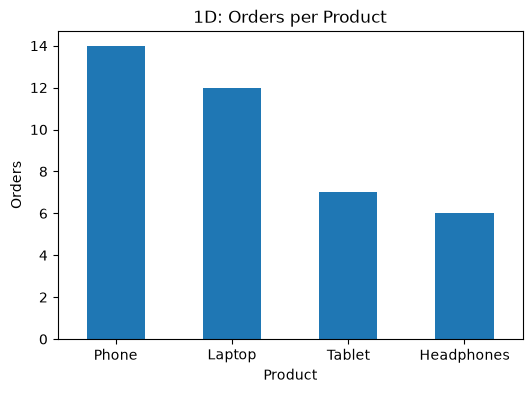

In [13]:
plt.figure(figsize=(6, 4))
df["Product"].value_counts().plot(kind="bar")
plt.xlabel("Product")
plt.ylabel("Orders")
plt.title("1D: Orders per Product")
plt.xticks(rotation=0)
plt.show()

logger.info("1D: Orders per Product plot generated ")

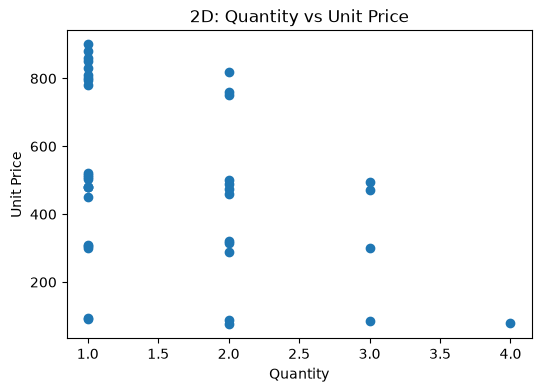

In [14]:
plt.figure(figsize=(6, 4))
plt.scatter(df["Quantity"], df["Unit_Price"])
plt.xlabel("Quantity")
plt.ylabel("Unit Price")
plt.title("2D: Quantity vs Unit Price")
plt.show()

logger.info("2D: Quantity vs Unit Price plot generated ")

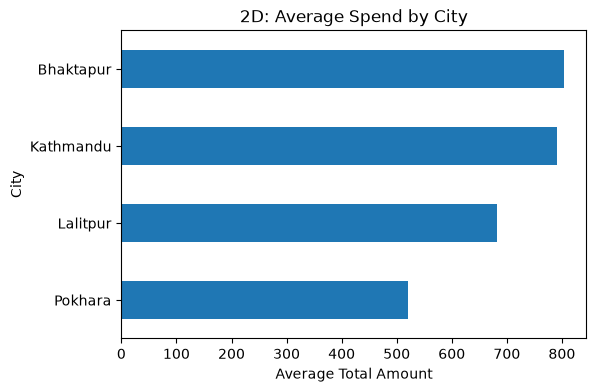

In [15]:
plt.figure(figsize=(6, 4))
df.groupby("City")["Total_Amount"].mean().sort_values().plot(kind="barh")
plt.xlabel("Average Total Amount")
plt.title("2D: Average Spend by City")
plt.show()

logger.info("2D: Average Spend by City plot generated ")

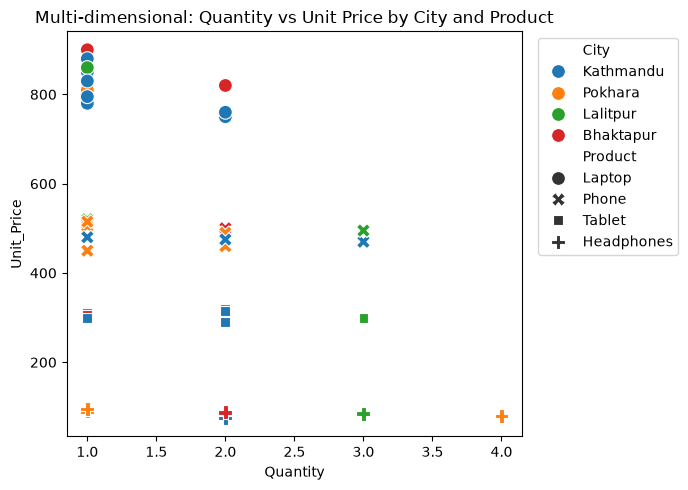

In [16]:
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x="Quantity", y="Unit_Price", hue="City", style="Product", s=100)
plt.title("Multi-dimensional: Quantity vs Unit Price by City and Product")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

logger.info("Multi-dimensional: Quantity vs Unit Price by City and Product plot generated ")

In [17]:
df.head(len(df))

,Customer_ID,Customer_Name,Email,City,Product,Quantity,Unit_Price,Order_Date,Gender,Age,Total_Amount
0,1001,John Smith,john.smith@email.com,Kathmandu,Laptop,2,750,5-Jan-26,Male,25,1500
1,1002,sita sharma,sita.sharma@email.com,Pokhara,Phone,1,450,1-May-26,Female,32,450
2,1003,Hari Thapa,hari.thapa@email.com,Kathmandu,Laptop,1,800,7-Jan-26,Male,28,800
3,1004,Gita Rai,gita.rai@email,Lalitpur,Tablet,3,300,8-Jan-26,Female,41,900
4,1005,Ram K.C.,NaN,Bhaktapur,Phone,2,500,9-Jan-26,Male,35,1000
5,1006,ANITA GURUNG,anita.gurung@email.com,Kathmandu,Laptop,1,850,1-Oct-26,Female,29,850
6,1007,Bikash Shrestha,bikash.shrestha@email.com,Pokhara,Headphones,4,80,11-Jan-26,Male,22,320
7,1008,Mina Tamang,mina.tamang@email.com,Kathmandu,Phone,1,480,12-Jan-26,Female,30,480
8,1009,Raju Lama,raju.lama@email.com,Lalitpur,Tablet,2,320,13-Jan-26,Male,38,640
9,1010,Pooja Adhikari,pooja.adhikari@email.com,Bhaktapur,Laptop,1,900,14-Jan-26,Female,27,900


In [19]:
logger.info("Day 1 completed successfully")